<div style="font-family: Arial, sans-serif; background-color: #f8f9fa; padding: 20px; border-radius: 10px; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);">
  <div style="display: flex; justify-content: space-between; align-items: center;">
    <img src="https://sigmoidal.ai/wp-content/uploads/2024/09/Academia-Sigmoidal-Light.png" alt="Academia Sigmoidal Logo" width="250" height="auto">
    <div style="text-align: right;">
<h1 style="color: #007bff; margin: 0; font-size: 24px;">Bootcamp de Visão Computacional Aplicada a Drones</h1>
    </div>
</div>
<hr style="border: none; height: 1px; background-color: #007bff; margin: 20px 0;">
<h3 style="color: #343a40; margin: 0; font-size: 20px;"><strong>Projeto 2 · Análise exploratória</strong></h3>
<p style="color: #6c757d; margin: 5px 0 0; font-size: 14px;"><strong>Instrutor:</strong> Carlos Melo, MSc.</p>
</div>

# Pessoas pequenas, dois sensores

Uma pessoa pode aparecer com clareza no térmico e quase desaparecer no RGB.
A análise do **RGBTDronePerson** permite entender o que cada sensor mostra,
como as pessoas foram anotadas e o que torna a detecção difícil.

Abra este notebook na pasta do Projeto 2 ou na raiz do repositório e selecione o kernel
**Projeto 2 - EDA**. Prepare o ambiente conforme o [README](README.md) e execute
`.venv-eda/bin/python suporte/preparar_dados.py --rgbtdroneperson` na pasta `projeto-2` para obter
os arquivos usados nesta análise. As células leem os dados de `dados/` e usam apenas CPU.
Execute-as em ordem.

In [1]:
from pathlib import Path
import json

DADOS = Path("dados")
if not (DADOS / "anotacoes-oficiais-extras").is_dir():
    DADOS = Path("projeto-2/dados")
ANOTACOES = DADOS / "anotacoes-oficiais-extras"

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11,
                     "figure.figsize": (8, 4), "figure.dpi": 110})

Matplotlib is building the font cache; this may take a moment.


## O que recebemos?

Cada exemplo contém um **par RGB + térmico** de 640 × 512 pixels.
Segundo o artigo, as imagens vieram de um DJI Mavic 2 Enterprise Advanced,
com voos predominantemente entre 50 e 80 metros, durante o dia e a noite.

Os JSONs oficiais seguem a organização COCO. `images` descreve os arquivos;
`annotations` contém as caixas. A tabela conta **pares e anotações**,
incluindo a categoria `uncertain`; não é uma contagem de pessoas distintas.

In [3]:
documentos = {}
resumo = []
for particao in ("train", "val"):
    arquivo = ANOTACOES / f"{particao}_thermal.json"
    doc = json.loads(arquivo.read_text())
    documentos[particao] = doc
    resumo.append([particao, len(doc["images"]), len(doc["annotations"])])
pd.DataFrame(resumo, columns=["Partição", "Pares", "Anotações"])

,Partição,Pares,Anotações
0,train,4900,56314
1,val,1225,14566


São **6.125 pares**, distribuídos entre treino e validação.
Cada par contém duas imagens, mas representa um único exemplo multimodal.
A exploração estatística a seguir usará as anotações de treino.

## Como os dois sensores enxergam a mesma cena?

Antes de mostrar as caixas, tente localizar as pessoas nas imagens.
O RGB aparece à esquerda e o térmico à direita. Os dois exemplos foram
escolhidos visualmente para contrastar boa iluminação e uma cena noturna.

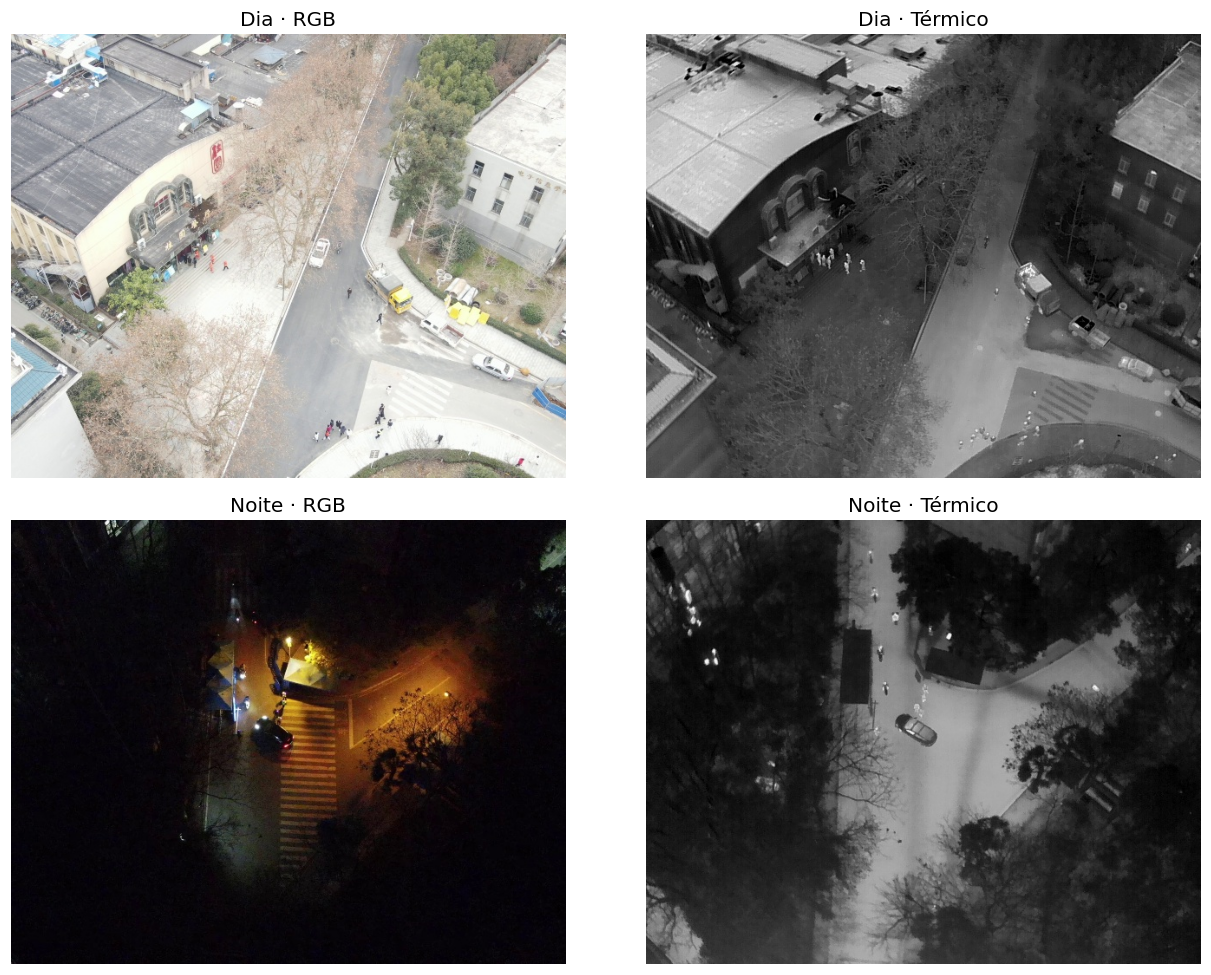

In [4]:
exemplos = [("train", "01000.jpg", "Dia"), ("val", "04900.jpg", "Noite")]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for linha, (particao, nome, cena) in enumerate(exemplos):
    for coluna, (sensor, titulo) in enumerate((("visible", "RGB"), ("thermal", "Térmico"))):
        imagem = Image.open(DADOS / particao / sensor / nome)
        axes[linha, coluna].imshow(imagem)
        axes[linha, coluna].set_title(f"{cena} · {titulo}")
        axes[linha, coluna].axis("off")
plt.tight_layout()
plt.show()

Na cena noturna, a informação do RGB se concentra perto da iluminação pública.
No térmico, pessoas e partes da rua também aparecem em regiões escuras no RGB.
O contraste depende da cena: uma pessoa não será necessariamente mais clara que o fundo.
Os tons destes JPEGs **não fornecem diretamente temperaturas em graus**.

## O que foi anotado como objeto?

As anotações usam quatro categorias:

- **person:** pessoa individual.
- **rider:** pessoa em bicicleta ou scooter.
- **crowd:** grupo cujas pessoas não puderam ser separadas na anotação.
- **uncertain:** objeto cuja identificação como pessoa é incerta.

Cada caixa COCO contém `[x, y, largura, altura]`, em pixels.
`(x, y)` é o canto superior esquerdo; `x` cresce para a direita e `y` para baixo.

In [5]:
treino = documentos["train"]
classes = {c["id"]: c["name"] for c in treino["categories"]}
caixas = pd.DataFrame(treino["annotations"])
caixas["classe"] = caixas["category_id"].map(classes)
caixas[["x", "y", "largura", "altura"]] = pd.DataFrame(caixas["bbox"].tolist())
caixas[["image_id", "classe", "x", "y", "largura", "altura"]].head()

,image_id,classe,x,y,largura,altura
0,0,crowd,329,343,16,28
1,1,person,615,3,16,14
2,2,person,528,41,12,16
3,3,person,176,30,18,21
4,4,person,174,313,14,17


A cena diurna será mostrada com suas **caixas térmicas**.
A visualização usa azul para `person`, laranja para `rider` e roxo para `crowd`.
A mesma paleta aparecerá na contagem por classe.

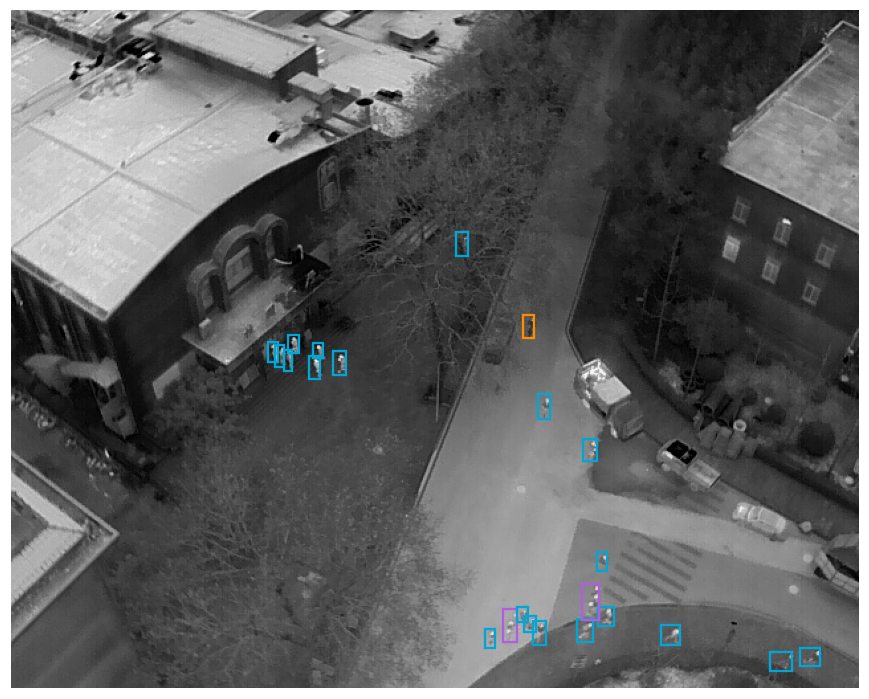

In [6]:
exemplo = treino["images"][1000]
termica = Image.open(DADOS / "train/thermal" / exemplo["file_name"])
objetos = caixas[caixas["image_id"] == exemplo["id"]]
cores = {"person": "#00A6D6", "rider": "#FF8C00", "crowd": "#B35CE2", "uncertain": "#888888"}
plt.figure(figsize=(10, 8))
plt.imshow(termica)
for objeto in objetos.itertuples():
    retangulo = Rectangle((objeto.x, objeto.y), objeto.largura, objeto.altura,
                          fill=False, edgecolor=cores[objeto.classe], linewidth=1.5)
    plt.gca().add_patch(retangulo)
plt.axis("off")
plt.show()

A contagem abaixo reúne as anotações de **todo o treino**, mantendo `uncertain` visível.
Uma caixa de `crowd` representa um grupo, não uma pessoa individual.

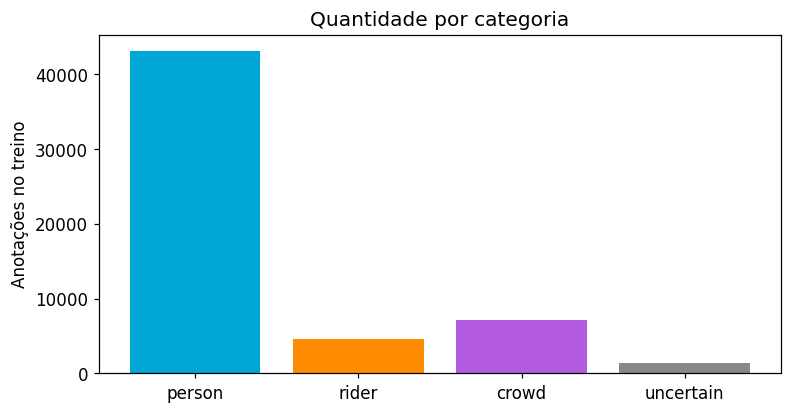

In [7]:
contagens = caixas["classe"].value_counts().reindex(cores)
plt.bar(contagens.index, contagens.values, color=list(cores.values()))
plt.ylabel("Anotações no treino")
plt.title("Quantidade por categoria")
plt.show()

`person` é a categoria mais frequente. O detector oficial usa
**person, rider e crowd**; `uncertain` fica fora do treinamento e da avaliação.
As contagens deste gráfico vêm dos arquivos locais, não de uma transcrição do artigo.

Nos JSONs, os totais de treino + validação são **54.178 person, 6.080 rider e 9.176 crowd**,
iguais aos totais do artigo. A distribuição entre as partições difere: o treino dos JSONs tem
43.169, 4.633 e 7.172 caixas, respectivamente; a seção 3.1 informa 43.006, 4.869 e 7.316.
Preservamos as divisões dos arquivos oficiais, sem redistribuir exemplos para ajustar a tabela.

## Quão pequenas são essas pessoas?

O tamanho aparente será medido pela raiz quadrada da área da caixa:

$$s = \sqrt{w h}$$

Aqui, $w$ é a largura e $h$ é a altura, em pixels. $s$ representa o lado
de um quadrado com a mesma área da caixa, e não a altura da pessoa.
O cálculo considera a proporção com $s < 20$ nas **três classes do treino**, excluindo `uncertain`.

In [8]:
validas = caixas[caixas["classe"] != "uncertain"].copy()
validas["tamanho"] = np.sqrt(validas["largura"] * validas["altura"])
percentual = 100 * (validas["tamanho"] < 20).mean()
print(f"Caixas do treino com tamanho abaixo de 20 pixels: {percentual:.1f}%")

Caixas do treino com tamanho abaixo de 20 pixels: 98.3%


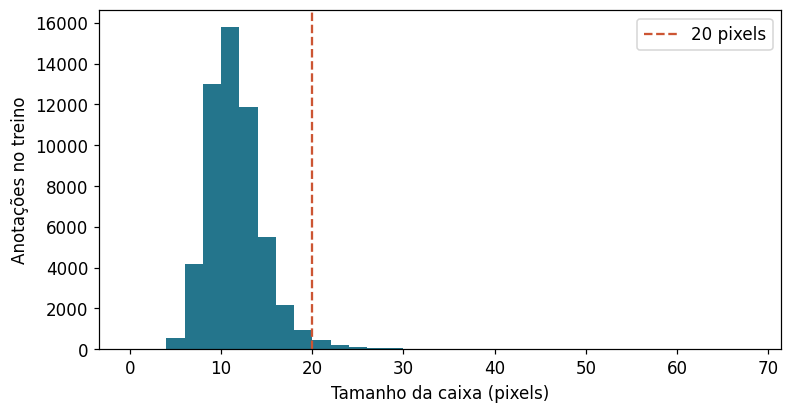

In [9]:
plt.hist(validas["tamanho"], bins=np.arange(0, 70, 2), color="#24758C")
plt.axvline(20, color="#CC5533", linestyle="--", label="20 pixels")
plt.xlabel("Tamanho da caixa (pixels)")
plt.ylabel("Anotações no treino")
plt.legend()
plt.show()

O treino resulta em aproximadamente **98,3%** de caixas com tamanho abaixo de 20 pixels.
A tabela abaixo repete o cálculo para treino, validação e o conjunto completo, sempre excluindo `uncertain`.
O desvio padrão é populacional (`ddof=0`).

No conjunto completo, obtemos **98,06%**, média **11,70 px** e desvio **3,25 px**.
São valores próximos dos 98,0% e 11,7 ± 3,4 px do artigo, mas não uma reprodução exata:
98,06% arredonda para 98,1% com uma casa decimal. A seção 3.1 atribui 98,0% ao treino;
a seção 3.2 apresenta esse percentual para o conjunto. Essa diferença exige explicitar o recorte
e o filtro usados, em vez de atribuir uma origem certa ao número publicado.

In [10]:
tamanhos = {}
for particao, doc in documentos.items():
    categorias = {c["id"]: c["name"] for c in doc["categories"]}
    tamanhos[particao] = np.array([
        np.sqrt(a["bbox"][2] * a["bbox"][3]) for a in doc["annotations"]
        if categorias[a["category_id"]] != "uncertain"
    ])
tamanhos["total"] = np.concatenate(list(tamanhos.values()))
estatisticas = [[p, len(s), 100 * (s < 20).mean(), s.mean(), s.std(ddof=0)]
                for p, s in tamanhos.items()]
pd.DataFrame(estatisticas, columns=["Partição", "Caixas", "< 20 px (%)", "Média (px)", "DP (px)"]).round(2)

,Partição,Caixas,< 20 px (%),Média (px),DP (px)
0,train,54974,98.32,11.58,3.19
1,val,14460,97.07,12.16,3.42
2,total,69434,98.06,11.70,3.25


A distribuição mostra como poucos pixels precisam descrever cada alvo.
A ampliação abaixo mostra uma pessoa da cena diurna, usando sua caixa original.

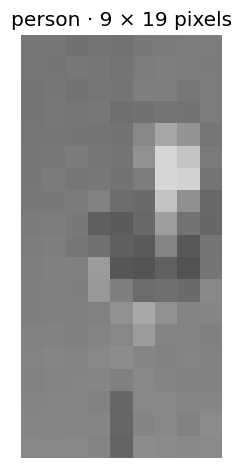

In [11]:
alvo = caixas.loc[caixas["id"] == 9581].iloc[0]
x, y, w, h = map(int, alvo["bbox"])
plt.figure(figsize=(3, 5))
plt.imshow(termica.crop((x, y, x + w, y + h)), interpolation="nearest")
plt.title(f"person · {w} × {h} pixels")
plt.axis("off")
plt.show()

A ampliação torna os pixels visíveis, mas **não acrescenta detalhes**.
Esta caixa tem 9 × 19 pixels. A largura de nove pixels ajuda a entender
por que pequenos deslocamentos podem prejudicar a localização do alvo.

## As imagens estão perfeitamente alinhadas?

O próximo recorte mostra uma região de 60 × 50 pixels ao redor da mesma pessoa.
Os limites do recorte serão iguais no RGB e no térmico.

In [12]:
rgb = Image.open(DADOS / "train/visible" / exemplo["file_name"])
x0, y0, x1, y1 = 365, 275, 425, 325
regiao = (x0, y0, x1, y1)

A **mesma caixa térmica** será desenhada nas duas imagens.
Subtrair `(x0, y0)` apenas expressa a caixa nas coordenadas do recorte;
isso não alinha os sensores nem cria uma anotação RGB.

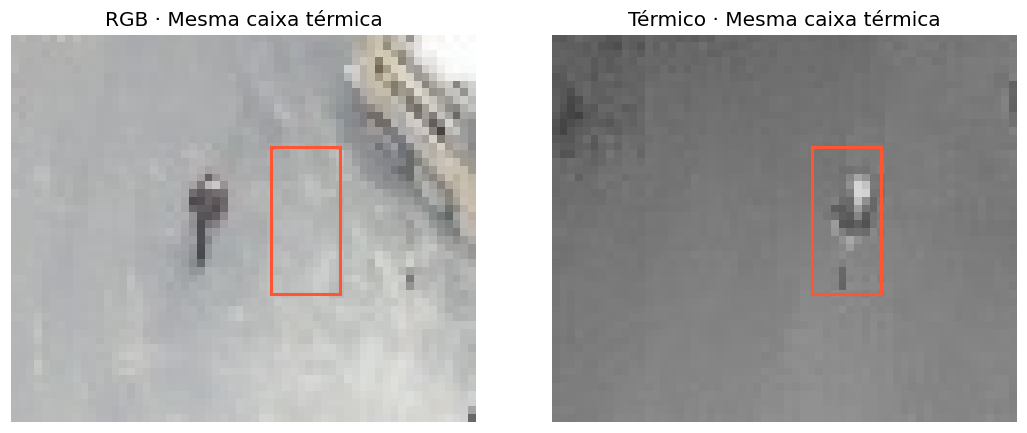

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, imagem, titulo in zip(axes, [rgb, termica], ["RGB", "Térmico"]):
    ax.imshow(imagem.crop(regiao), interpolation="nearest")
    ax.add_patch(Rectangle((x - x0, y - y0), w, h, fill=False,
                           edgecolor="#FF5533", linewidth=2))
    ax.set_title(titulo + " · Mesma caixa térmica")
    ax.axis("off")
plt.tight_layout()
plt.show()

A caixa envolve a pessoa no térmico, mas fica à direita dela no RGB.
**Arquivos pareados não garantem alinhamento geométrico.** Neste dataset,
as anotações completas usam o referencial térmico.

A análise evidencia três desafios que motivam o projeto: **objetos minúsculos**,
**informação complementar entre sensores** e **desalinhamento**.
Essas observações vão orientar a preparação do detector multimodal.

**Fontes:** Zhang et al. (2023),
[Drone-based RGBT tiny person detection](https://doi.org/10.1016/j.isprsjprs.2023.08.016),
seção 3 e figuras 2–3; [página oficial do dataset](https://nnnnerd.github.io/RGBTDronePerson/).